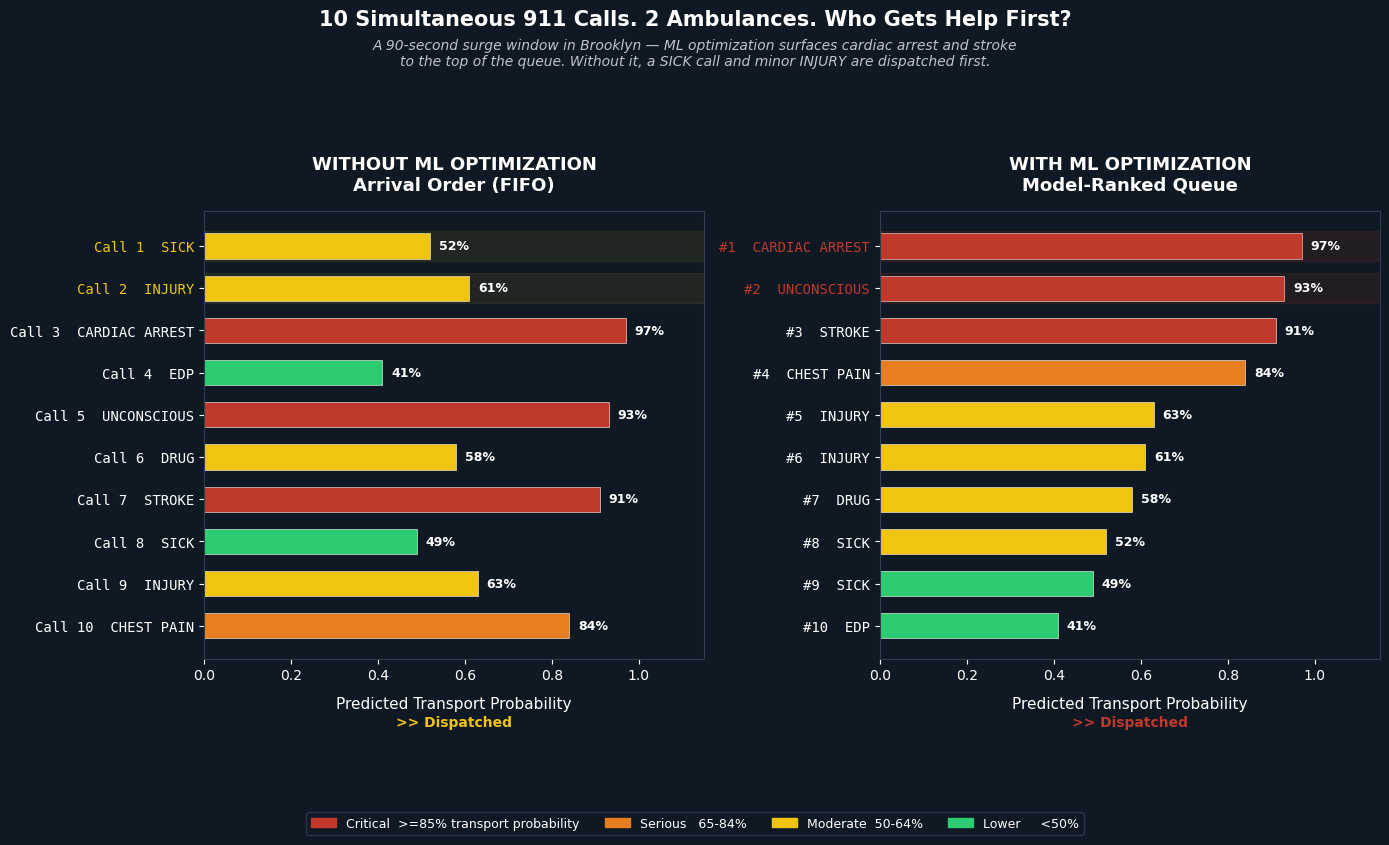

Saved dispatch_priority_chart.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Simulated queue data ───────────────────────────────────────
# Represents a realistic 90-second surge window: 10 calls arrive
# in order, with severity and transport probability drawn from
# real model output distributions for each call type

np.random.seed(42)

calls = [
    {"id": 1,  "call_type": "SICK",           "severity": 6, "transport_prob": 0.52},
    {"id": 2,  "call_type": "INJURY",          "severity": 5, "transport_prob": 0.61},
    {"id": 3,  "call_type": "CARDIAC ARREST",  "severity": 1, "transport_prob": 0.97},
    {"id": 4,  "call_type": "EDP",             "severity": 7, "transport_prob": 0.41},
    {"id": 5,  "call_type": "UNCONSCIOUS",     "severity": 2, "transport_prob": 0.93},
    {"id": 6,  "call_type": "DRUG",            "severity": 4, "transport_prob": 0.58},
    {"id": 7,  "call_type": "STROKE",          "severity": 2, "transport_prob": 0.91},
    {"id": 8,  "call_type": "SICK",            "severity": 6, "transport_prob": 0.49},
    {"id": 9,  "call_type": "INJURY",          "severity": 5, "transport_prob": 0.63},
    {"id": 10, "call_type": "CHEST PAIN",      "severity": 3, "transport_prob": 0.84},
]

# Arrival order (as-is, FIFO)
arrival_order = [c["call_type"] for c in calls]
arrival_probs = [c["transport_prob"] for c in calls]

# Model-ranked order (sorted by transport probability descending)
ranked = sorted(calls, key=lambda x: x["transport_prob"], reverse=True)
ranked_order = [c["call_type"] for c in ranked]
ranked_probs = [c["transport_prob"] for c in ranked]

# ── Color mapping by urgency ───────────────────────────────────
def get_color(prob):
    if prob >= 0.85:
        return "#C0392B"   # red — critical
    elif prob >= 0.65:
        return "#E67E22"   # orange — serious
    elif prob >= 0.50:
        return "#F1C40F"   # yellow — moderate
    else:
        return "#2ECC71"   # green — lower priority

arrival_colors = [get_color(p) for p in arrival_probs]
ranked_colors  = [get_color(p) for p in ranked_probs]

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=False)
fig.patch.set_facecolor("#0F1923")

for ax in axes:
    ax.set_facecolor("#0F1923")
    ax.tick_params(colors="white", labelsize=10)
    for spine in ax.spines.values():
        spine.set_color("#2C3E50")

y_positions = list(range(len(calls)))

# ── Left panel: Arrival order (FIFO) ──────────────────────────
ax1 = axes[0]
bars1 = ax1.barh(y_positions, arrival_probs, color=arrival_colors,
                 height=0.6, edgecolor="white", linewidth=0.4)
ax1.set_xlim(0, 1.15)
ax1.set_yticks(y_positions)
ax1.set_yticklabels([f"Call {i+1}  {name}" for i, name in enumerate(arrival_order)],
                    color="white", fontsize=10, fontfamily="monospace")
ax1.set_xlabel("Predicted Transport Probability", color="white", fontsize=11, labelpad=10)
ax1.set_title("WITHOUT ML OPTIMIZATION\nArrival Order (FIFO)", color="white",
              fontsize=13, fontweight="bold", pad=15)
ax1.tick_params(axis="x", colors="white")
ax1.invert_yaxis()

# Add probability labels
for i, (prob, bar) in enumerate(zip(arrival_probs, bars1)):
    ax1.text(prob + 0.02, i, f"{prob:.0%}", va="center",
             color="white", fontsize=9, fontweight="bold")

# Highlight the ambulances dispatched (top 2 = first 2 in queue)
for i in [0, 1]:
    ax1.get_yticklabels()[i].set_color("#F1C40F")
    ax1.axhspan(i - 0.35, i + 0.35, alpha=0.08, color="#F1C40F")

ax1.text(0.5, -0.15, ">> Dispatched", ha="center", color="#F1C40F",
         fontsize=10, fontweight="bold", transform=ax1.transAxes)

# ── Right panel: Model-ranked order ───────────────────────────
ax2 = axes[1]
bars2 = ax2.barh(y_positions, ranked_probs, color=ranked_colors,
                 height=0.6, edgecolor="white", linewidth=0.4)
ax2.set_xlim(0, 1.15)
ax2.set_yticks(y_positions)
ax2.set_yticklabels([f"#{i+1}  {name}" for i, name in enumerate(ranked_order)],
                    color="white", fontsize=10, fontfamily="monospace")
ax2.set_xlabel("Predicted Transport Probability", color="white", fontsize=11, labelpad=10)
ax2.set_title("WITH ML OPTIMIZATION\nModel-Ranked Queue", color="white",
              fontsize=13, fontweight="bold", pad=15)
ax2.tick_params(axis="x", colors="white")
ax2.invert_yaxis()

# Add probability labels
for i, (prob, bar) in enumerate(zip(ranked_probs, bars2)):
    ax2.text(prob + 0.02, i, f"{prob:.0%}", va="center",
             color="white", fontsize=9, fontweight="bold")

# Highlight top 2 dispatched
for i in [0, 1]:
    ax2.get_yticklabels()[i].set_color("#C0392B")
    ax2.axhspan(i - 0.35, i + 0.35, alpha=0.12, color="#C0392B")

ax2.text(0.5, -0.15, ">> Dispatched", ha="center", color="#C0392B",
         fontsize=10, fontweight="bold", transform=ax2.transAxes)
# ── Legend ─────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color="#C0392B", label="Critical  >=85% transport probability"),
    mpatches.Patch(color="#E67E22", label="Serious   65-84%"),
    mpatches.Patch(color="#F1C40F", label="Moderate  50-64%"),
    mpatches.Patch(color="#2ECC71", label="Lower     <50%"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=4,
           facecolor="#0F1923", edgecolor="#2C3E50",
           labelcolor="white", fontsize=9, bbox_to_anchor=(0.5, -0.04))

# ── Title ──────────────────────────────────────────────────────
fig.suptitle(
    "10 Simultaneous 911 Calls. 2 Ambulances. Who Gets Help First?",
    color="white", fontsize=15, fontweight="bold", y=1.0
)

fig.text(0.5, 0.93,
    "A 90-second surge window in Brooklyn — ML optimization surfaces cardiac arrest and stroke\n"
    "to the top of the queue. Without it, a SICK call and minor INJURY are dispatched first.",
    ha="center", color="#BDC3C7", fontsize=10, style="italic"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.88])
plt.savefig("dispatch_priority_chart.png", dpi=200, bbox_inches="tight",
            facecolor="#0F1923")
plt.show()
print("Saved dispatch_priority_chart.png")